# Integrated Gradients en Visión: Sensibilidad al Baseline y LIME vs. IG

En O1 implementamos IG desde cero para texto. Aquí llevamos IG al dominio de **imágenes** con tres objetivos concretos:

1. **Baseline sensitivity**: demostrar que la elección del baseline no es un detalle de implementación sino una decisión semántica con consecuencias directas sobre *qué explica* el método
2. **Técnicas de visualización** específicas para atribuciones 2D (signed, overlay, norma L2)
3. **LIME vs. IG**: comparar metodologías model-agnostic vs. gradient-based en el mismo caso de uso



In [6]:
# !pip install torchvision lime scikit-image requests Pillow  # Descomentar si es necesario

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO

from torchvision.models import resnet50, ResNet50_Weights
from torchvision.transforms.functional import gaussian_blur

from captum.attr import IntegratedGradients, LayerGradCam

plt.style.use('ggplot')
torch.manual_seed(42)
np.random.seed(42)

print('✓ Imports listos')

✓ Imports listos


## 1. Modelo: ResNet50 preentrenado en ImageNet-1K



In [7]:
weights = ResNet50_Weights.IMAGENET1K_V2
model = resnet50(weights=weights)
model.eval()  # Desactivar Dropout y BatchNorm en modo inferencia

preprocess = weights.transforms()          # Resize(232) → CenterCrop(224) → Normalize
imagenet_labels = weights.meta['categories']  # Lista de 1000 etiquetas

print(f'✓ Modelo: ResNet50 (IMAGENET1K_V2)')
print(f'✓ Parámetros totales: {sum(p.numel() for p in model.parameters()):,}')
print(f'✓ Número de clases: {len(imagenet_labels)}')
print(f'✓ Transformaciones: {preprocess}')

✓ Modelo: ResNet50 (IMAGENET1K_V2)
✓ Parámetros totales: 25,557,032
✓ Número de clases: 1000
✓ Transformaciones: ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## 2. Imagen de Prueba



✓ Imagen cargada desde disco: sample_image.jpg
✓ Imagen PIL: (1546, 1213) px (W×H)
✓ Tensor preprocesado shape: (1, 3, 224, 224)
✓ Rango del tensor: [-2.101, 2.640]

=== TOP 5 PREDICCIONES ===
  1. Samoyed                        0.4366 (43.7%)
  2. white wolf                     0.0211 (2.1%)
  3. Pomeranian                     0.0132 (1.3%)
  4. Great Pyrenees                 0.0080 (0.8%)
  5. Eskimo dog                     0.0059 (0.6%)

✓ Clase objetivo para IG: 258 — "Samoyed"


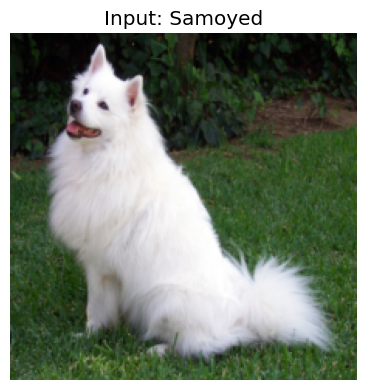

In [8]:
import os

# Cargamos imagen local (sample_image.jpg, incluida junto al notebook)
# Fallback: descarga desde PyTorch Hub
IMG_PATH = 'sample_image.jpg'

img_pil = Image.open(IMG_PATH).convert('RGB')
print(f'✓ Imagen cargada desde disco: {IMG_PATH}')

img_tensor = preprocess(img_pil).unsqueeze(0)  # (1, 3, 224, 224)
img_224 = img_pil.resize((224, 224), Image.BILINEAR)  # Version PIL para visualizacion

print(f'✓ Imagen PIL: {img_pil.size} px (W×H)')
print(f'✓ Tensor preprocesado shape: {tuple(img_tensor.shape)}')
print(f'✓ Rango del tensor: [{img_tensor.min():.3f}, {img_tensor.max():.3f}]')

# Forward pass para verificar prediccion
with torch.no_grad():
    logits = model(img_tensor)          # (1, 1000)
    probs  = F.softmax(logits, dim=-1)  # (1, 1000)

top5_probs, top5_idx = torch.topk(probs[0], 5)

print('\n=== TOP 5 PREDICCIONES ===')
for i, (p, idx) in enumerate(zip(top5_probs, top5_idx)):
    print(f'  {i+1}. {imagenet_labels[idx.item()]:<30} {p.item():.4f} ({p.item()*100:.1f}%)')

clase_objetivo = top5_idx[0].item()
print(f'\n✓ Clase objetivo para IG: {clase_objetivo} — "{imagenet_labels[clase_objetivo]}"')

plt.figure(figsize=(4, 4))
plt.imshow(img_224)
plt.title(f'Input: {imagenet_labels[clase_objetivo]}')
plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Integrated Gradients con Captum sobre Imágenes



In [9]:
def forward_func(x):
    '''Devuelve el logit de la clase objetivo — escalar por muestra del batch.'''
    return model(x)[:, clase_objetivo]

ig = IntegratedGradients(forward_func)
baseline_negro = torch.zeros_like(img_tensor)  # x' = 0

print('=== DEBUG IG EN IMAGEN ===')
print(f'Input shape:         {tuple(img_tensor.shape)}')
print(f'Baseline shape:      {tuple(baseline_negro.shape)}')
print(f'n_steps:             50')

attributions_base, delta_base = ig.attribute(
    inputs=img_tensor,
    baselines=baseline_negro,
    n_steps=50,
    return_convergence_delta=True
)

print(f'\nAttributions shape:  {tuple(attributions_base.shape)}')
print(f'Delta (error):       {delta_base.item():.4f}')

# Suma sobre canal RGB → mapa 2D con signo
attr_map_signed = attributions_base.squeeze(0).sum(dim=0).detach().numpy()   # (H, W)
# Norma L2 sobre canales → magnitud sin signo
attr_map_norm   = attributions_base.squeeze(0).norm(dim=0).detach().numpy()  # (H, W)

print(f'Mapa signed shape:   {attr_map_signed.shape}')
print(f'Rango signed:        [{attr_map_signed.min():.4f}, {attr_map_signed.max():.4f}]')

=== DEBUG IG EN IMAGEN ===
Input shape:         (1, 3, 224, 224)
Baseline shape:      (1, 3, 224, 224)
n_steps:             50

Attributions shape:  (1, 3, 224, 224)
Delta (error):       1.7453
Mapa signed shape:   (224, 224)
Rango signed:        [-0.5887, 0.4692]


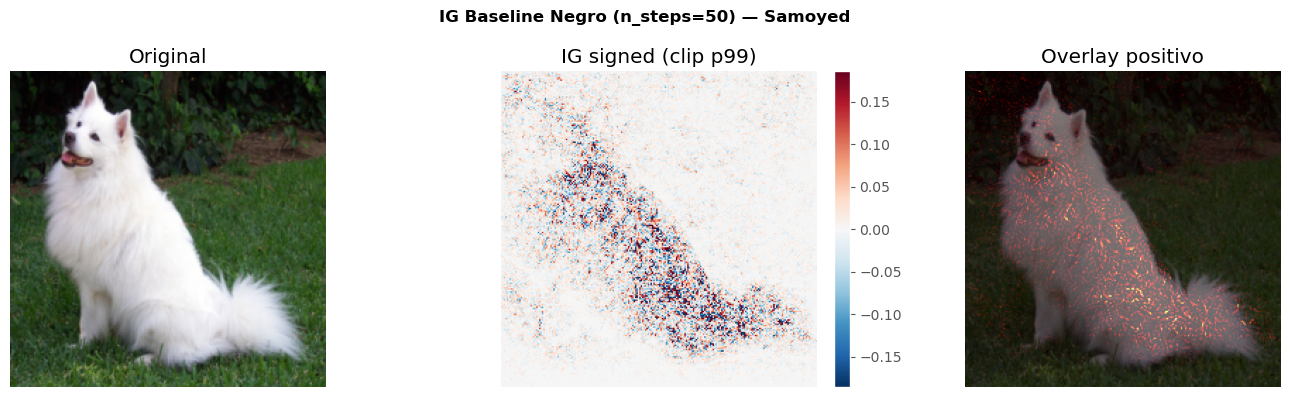

In [10]:
def visualizar_ig(img_pil_orig, attr_map, titulo='IG Attribution', percentil=99):
    '''
    Muestra 3 vistas de las atribuciones IG sobre una imagen.
    - Columna 1: imagen original
    - Columna 2: mapa IG signed (rojo=positivo, azul=negativo)
    - Columna 3: overlay de atribuciones positivas sobre la imagen
    '''
    img_np = np.array(img_pil_orig.resize((224, 224), Image.BILINEAR)) / 255.0
    vmax   = np.percentile(np.abs(attr_map), percentil)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].imshow(img_np)
    axes[0].set_title('Original')
    axes[0].axis('off')

    im = axes[1].imshow(attr_map, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[1].set_title(f'IG signed (clip p{percentil})')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    attr_pos      = np.clip(attr_map, 0, None)
    attr_pos_norm = attr_pos / (attr_pos.max() + 1e-8)
    axes[2].imshow(img_np)
    axes[2].imshow(attr_pos_norm, cmap='hot', alpha=0.55)
    axes[2].set_title('Overlay positivo')
    axes[2].axis('off')

    plt.suptitle(titulo, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualizar_ig(img_pil, attr_map_signed,
              f'IG Baseline Negro (n_steps=50) — {imagenet_labels[clase_objetivo]}')

## 4. Sensibilidad al Baseline: El Problema Más Subestimado de IG


In [11]:
mean_imagenet = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).expand_as(img_tensor).clone()

baselines = {
    'Negro (zeros)':    torch.zeros_like(img_tensor),
    'Blanco (ones)':    torch.ones_like(img_tensor),
    'Ruido gaussiano':  torch.randn_like(img_tensor) * 0.5,
    'Blur (kernel=51)': gaussian_blur(img_tensor, kernel_size=[51, 51], sigma=[20.0, 20.0]),
    'Media ImageNet':   mean_imagenet,
}

print('Baselines definidos:')
for nombre, bl in baselines.items():
    print(f'  {nombre:<22} mean={bl.mean():.4f}  std={bl.std():.4f}')

# n_steps=50 — suficiente para comparar patrones entre baselines
resultados = {}
print('\n=== CALCULANDO IG PARA CADA BASELINE (n_steps=50) ===')
for nombre, baseline in baselines.items():
    attrs, delta = ig.attribute(
        inputs=img_tensor,
        baselines=baseline,
        n_steps=50,
        return_convergence_delta=True
    )
    attr_2d = attrs.squeeze(0).sum(dim=0).detach().numpy()
    resultados[nombre] = {'attrs': attr_2d, 'delta': delta.item()}
    print(f'  {nombre:<22} delta={delta.item():+.4f}  L1={np.abs(attr_2d).mean():.4f}')

Baselines definidos:
  Negro (zeros)          mean=0.0000  std=0.0000
  Blanco (ones)          mean=1.0000  std=0.0000
  Ruido gaussiano        mean=0.0025  std=0.5008
  Blur (kernel=51)       mean=0.0979  std=1.2187
  Media ImageNet         mean=0.4490  std=0.0326

=== CALCULANDO IG PARA CADA BASELINE (n_steps=50) ===
  Negro (zeros)          delta=+1.7453  L1=0.0239
  Blanco (ones)          delta=-4.3539  L1=0.0189
  Ruido gaussiano        delta=-1.0737  L1=0.0059
  Blur (kernel=51)       delta=+1.7589  L1=0.0052
  Media ImageNet         delta=-6.8066  L1=0.0211


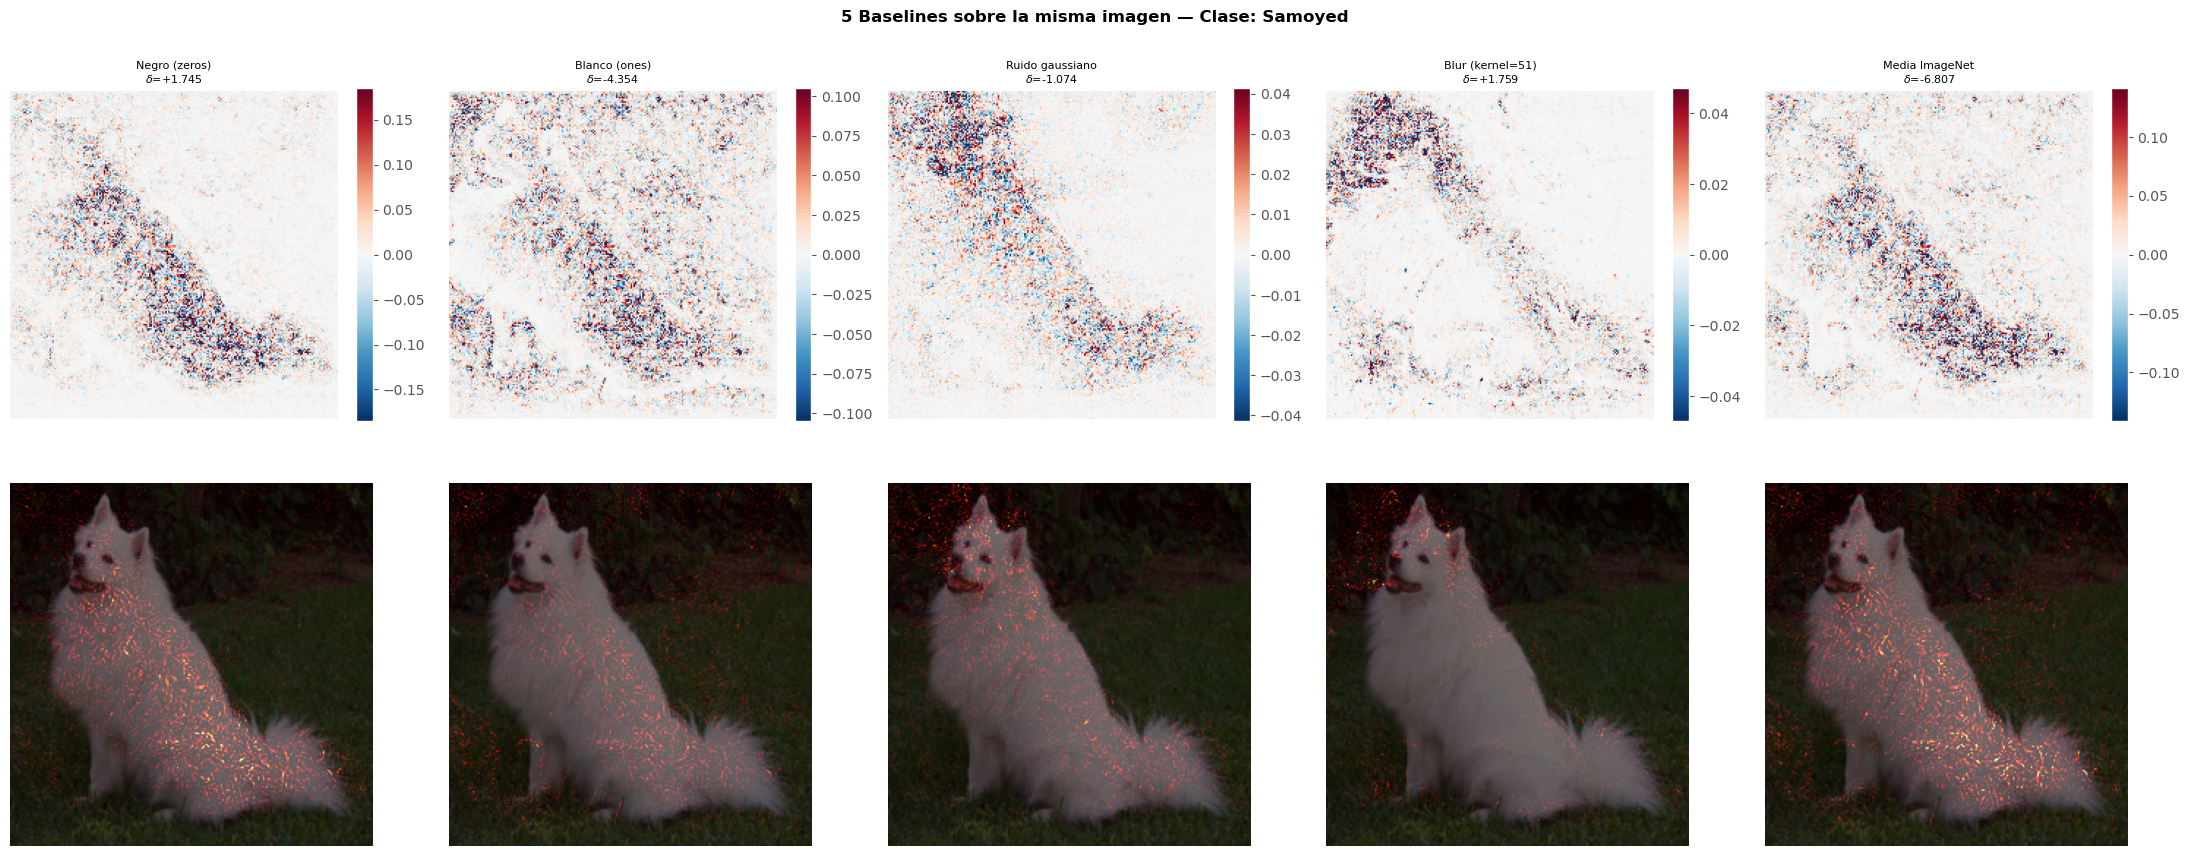

In [12]:
img_np = np.array(img_pil.resize((224, 224), Image.BILINEAR)) / 255.0
fig, axes = plt.subplots(2, 5, figsize=(22, 9))

for col, (nombre, res) in enumerate(resultados.items()):
    attr = res['attrs']
    vmax = np.percentile(np.abs(attr), 99)

    # Fila 0: mapa signed
    im = axes[0, col].imshow(attr, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[0, col].set_title(f'{nombre}\n$\\delta$={res["delta"]:+.3f}', fontsize=8)
    axes[0, col].axis('off')
    plt.colorbar(im, ax=axes[0, col], fraction=0.046)

    # Fila 1: overlay positivo
    attr_pos = np.clip(attr, 0, None)
    attr_pos_norm = attr_pos / (attr_pos.max() + 1e-8)
    axes[1, col].imshow(img_np)
    axes[1, col].imshow(attr_pos_norm, cmap='hot', alpha=0.6)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('IG signed', fontsize=9)
axes[1, 0].set_ylabel('Overlay positivo', fontsize=9)
plt.suptitle(f'5 Baselines sobre la misma imagen — Clase: {imagenet_labels[clase_objetivo]}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

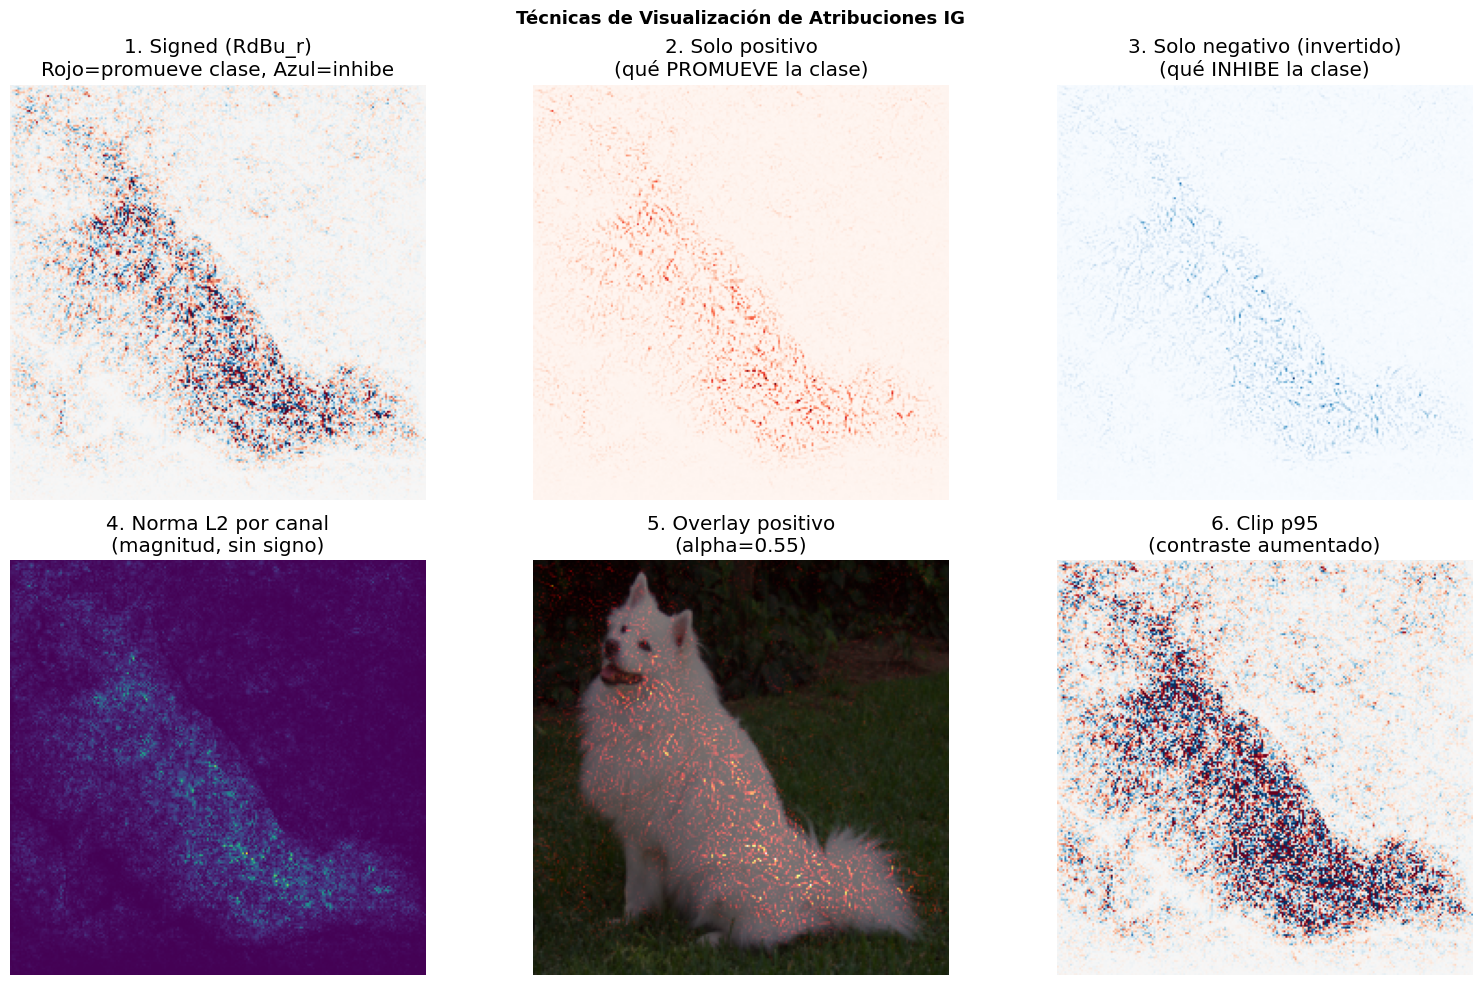

In [13]:
attr = resultados['Negro (zeros)']['attrs']  # Usamos el baseline negro de referencia
img_np = np.array(img_pil.resize((224, 224), Image.BILINEAR)) / 255.0

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Signed divergente
vmax = np.percentile(np.abs(attr), 99)
axes[0, 0].imshow(attr, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[0, 0].set_title('1. Signed (RdBu_r)\nRojo=promueve clase, Azul=inhibe')
axes[0, 0].axis('off')

# 2. Solo positivo — qué promueve la clase
axes[0, 1].imshow(np.clip(attr, 0, None), cmap='Reds')
axes[0, 1].set_title('2. Solo positivo\n(qué PROMUEVE la clase)')
axes[0, 1].axis('off')

# 3. Solo negativo — qué inhibe la clase
axes[0, 2].imshow(-np.clip(attr, None, 0), cmap='Blues')
axes[0, 2].set_title('3. Solo negativo (invertido)\n(qué INHIBE la clase)')
axes[0, 2].axis('off')

# 4. Norma L2 sobre canales — magnitud sin signo
norma_l2 = attributions_base.squeeze(0).norm(dim=0).detach().numpy()
axes[1, 0].imshow(norma_l2, cmap='viridis')
axes[1, 0].set_title('4. Norma L2 por canal\n(magnitud, sin signo)')
axes[1, 0].axis('off')

# 5. Overlay sobre imagen
attr_pos = np.clip(attr, 0, None)
axes[1, 1].imshow(img_np)
axes[1, 1].imshow(attr_pos / (attr_pos.max() + 1e-8), cmap='hot', alpha=0.55)
axes[1, 1].set_title('5. Overlay positivo\n(alpha=0.55)')
axes[1, 1].axis('off')

# 6. Clip por percentil p95 — mayor contraste
v95 = np.percentile(np.abs(attr), 95)
axes[1, 2].imshow(np.clip(attr, -v95, v95), cmap='RdBu_r')
axes[1, 2].set_title('6. Clip p95\n(contraste aumentado)')
axes[1, 2].axis('off')

plt.suptitle('Técnicas de Visualización de Atribuciones IG', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Comparación: IG vs. GradCAM



GradCAM attributions shape (pre-upsample): (1, 1, 7, 7)
GradCAM mapa final shape: (224, 224)


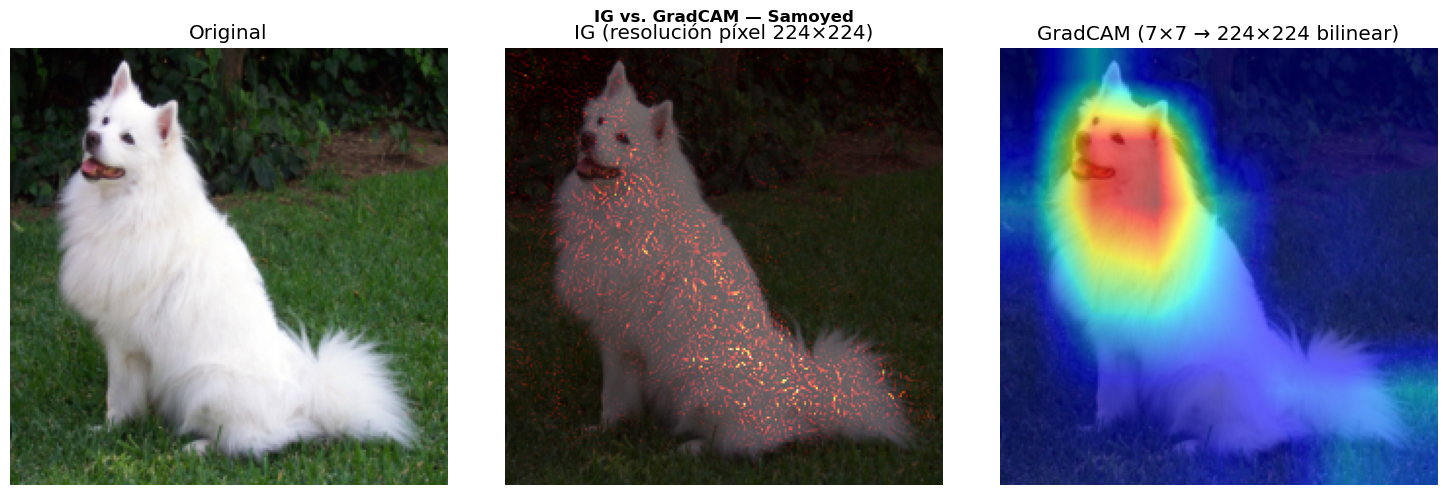

In [14]:
def forward_func_full(x):
    return model(x)  # (batch, 1000) — todos los logits

gradcam = LayerGradCam(forward_func_full, model.layer4)

gc_attrs = gradcam.attribute(img_tensor, target=clase_objetivo)
print(f'GradCAM attributions shape (pre-upsample): {tuple(gc_attrs.shape)}')

# Interpolacion bilineal a resolucion original
gc_up = F.interpolate(
    gc_attrs,
    size=(224, 224),
    mode='bilinear',
    align_corners=False
).squeeze().detach().numpy()

gc_up = np.maximum(gc_up, 0)           # ReLU semantico: solo regiones positivas
gc_up = gc_up / (gc_up.max() + 1e-8)  # Normalizar a [0, 1]

print(f'GradCAM mapa final shape: {gc_up.shape}')

attr_pos = np.clip(attr_map_signed, 0, None)
attr_pos_norm = attr_pos / (attr_pos.max() + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_np)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_np)
axes[1].imshow(attr_pos_norm, cmap='hot', alpha=0.6)
axes[1].set_title('IG (resolución píxel 224×224)')
axes[1].axis('off')

axes[2].imshow(img_np)
axes[2].imshow(gc_up, cmap='jet', alpha=0.6)
axes[2].set_title('GradCAM (7×7 → 224×224 bilinear)')
axes[2].axis('off')

plt.suptitle(f'IG vs. GradCAM — {imagenet_labels[clase_objetivo]}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Comparación: IG vs. LIME en Imágenes

LIME sobre imágenes trabaja con **superpíxeles** (regiones coherentes segmentadas, no píxeles individuales):

1. Segmentación de la imagen (quickshift, SLIC, Felzenszwalb)
2. Perturbación binaria: cada superpíxel se oculta con un color sólido o se mantiene
3. Ajuste de un modelo lineal local $g$ sobre el espacio de perturbaciones $\{0,1\}^S$

La comparación clave:

```
LIME:  model-agnostic  →  funciona con cualquier modelo, incluso APIs remotas
IG:    white-box        →  necesita acceso a los pesos y permite backpropagation
```

Una API de producción (OpenAI Vision, Google Cloud Vision) **no expone gradientes**. LIME puede explicarla; IG, no. El precio: LIME no satisface el axioma de completitud y su granularidad es la del superpíxel, no del píxel.

In [15]:

from lime import lime_image
from skimage.segmentation import mark_boundaries
LIME_OK = True
print('✓ LIME y scikit-image disponibles')

def batch_predict_resnet(images_np):
    '''
    Wrapper para LIME: convierte (N, H, W, C) float[0,1] → probabilidades.
    LIME llama a esta funcion con N perturbaciones a la vez.
    '''
    batch = torch.stack([
        preprocess(Image.fromarray((img * 255).astype(np.uint8)))
        for img in images_np
    ])  # (N, 3, 224, 224)
    with torch.no_grad():
        logits = model(batch)
        probs  = F.softmax(logits, dim=-1)
    return probs.numpy()  # (N, 1000)

# Test rapido: 1 imagen, shape esperado
img_224_np = np.array(img_pil.resize((224, 224), Image.BILINEAR)) / 255.0
test_out   = batch_predict_resnet([img_224_np])
print(f'✓ batch_predict_resnet output shape: {test_out.shape}')
print(f'  Clase predicha: {imagenet_labels[test_out[0].argmax()]} ({test_out[0].max():.4f})')

✓ LIME y scikit-image disponibles
✓ batch_predict_resnet output shape: (1, 1000)
  Clase predicha: Samoyed (0.4705)


Calculando LIME (num_samples=200, ~20-40s)...


100%|██████████| 200/200 [00:07<00:00, 25.55it/s]


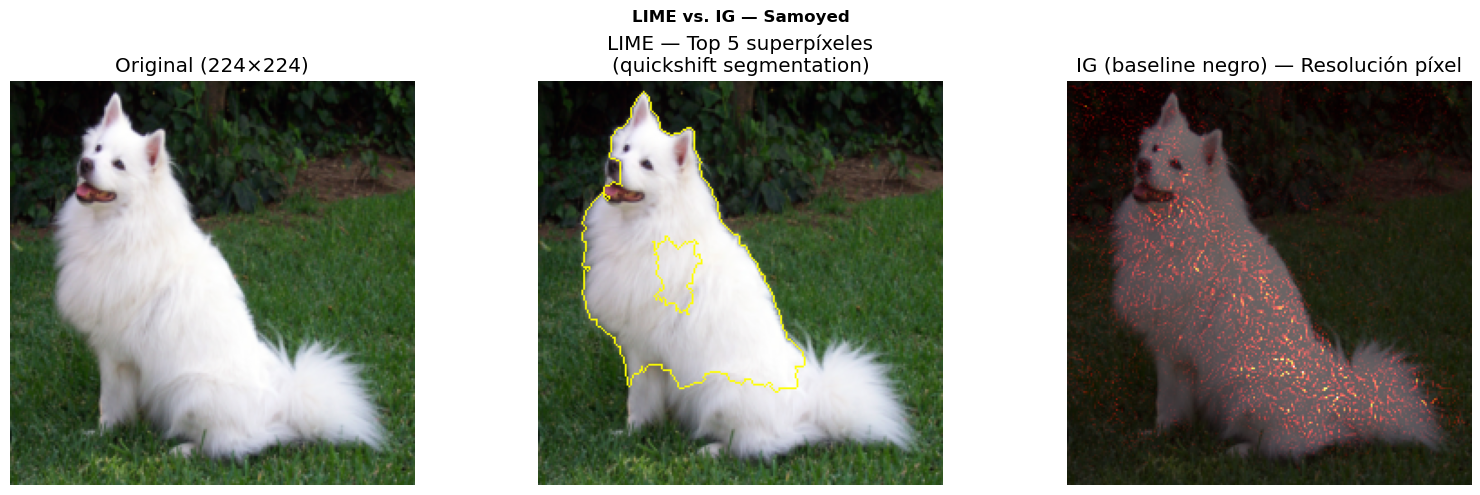


Característica               LIME                 IG
  Acceso al modelo           Agnostic (black-box) White-box (gradientes)
  Unidad de atribución       Superpíxel           Píxel
  Resolución (224×224)       ~100-300 regiones    50,176 px
  Axioma completitud         ✗ No                 ✓ Sí
  Costo cómputo              200 forward passes   50 forward+backward
  Determinismo               Estocástico          Determinista


In [16]:
explainer_lime = lime_image.LimeImageExplainer(random_state=42)

print('Calculando LIME (num_samples=200, ~20-40s)...')
explanation = explainer_lime.explain_instance(
    img_224_np,
    batch_predict_resnet,
    top_labels=1,
    hide_color=0,
    num_samples=200,   # Reducido para CPU (200 suficiente para el patron)
    random_seed=42
)

lime_img, lime_mask = explanation.get_image_and_mask(
    label=clase_objetivo,
    positive_only=True,
    num_features=5,
    hide_rest=False
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(img_224_np)
axes[0].set_title('Original (224×224)')
axes[0].axis('off')

axes[1].imshow(mark_boundaries(lime_img, lime_mask))
axes[1].set_title('LIME — Top 5 superpíxeles\n(quickshift segmentation)')
axes[1].axis('off')

axes[2].imshow(img_224_np)
attr_pos = np.clip(attr_map_signed, 0, None)
axes[2].imshow(attr_pos / (attr_pos.max() + 1e-8), cmap='hot', alpha=0.6)
axes[2].set_title('IG (baseline negro) — Resolución píxel')
axes[2].axis('off')

plt.suptitle(f'LIME vs. IG — {imagenet_labels[clase_objetivo]}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n' + '='*65)
print(f'{"Característica":<28} {"LIME":<20} {"IG"}')
print('='*65)
for row in [
    ('Acceso al modelo',     'Agnostic (black-box)',  'White-box (gradientes)'),
    ('Unidad de atribución', 'Superpíxel',            'Píxel'),
    ('Resolución (224×224)', '~100-300 regiones',     '50,176 px'),
    ('Axioma completitud',   '✗ No',                  '✓ Sí'),
    ('Costo cómputo',        '200 forward passes',    '50 forward+backward'),
    ('Determinismo',         'Estocástico',           'Determinista'),
]:
    print(f'  {row[0]:<26} {row[1]:<20} {row[2]}')
print('='*65)